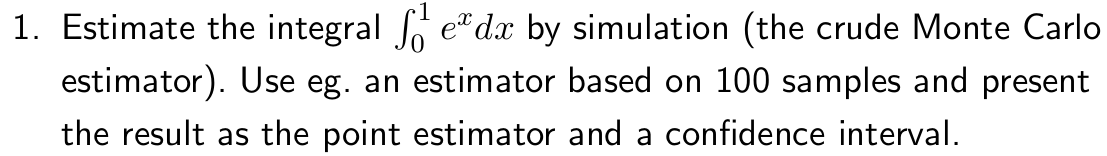

The general idea behind the crude Monte Carlo estimator is that we can write the integral as: 

$$\int_0^1e^xdx = E[e^{U}]$$

Where $U$ are uniformly generated random variables. We can thus generete values for $U$ and write $X_i = e^{U_i}$ and find the integtal as $E[X]$.

In [12]:
import numpy as np
from random import random

# Set seed
np.random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random())

U = np.array(U)
X = np.exp(U)

mean_X = np.mean(X)
print("Mean of X:", mean_X)

# Estimate confidence intervals
s2 = np.var(X, ddof=1)
alpha = 0.05
lower_bound = mean_X - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_X + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of X: [{lower_bound}, {upper_bound}]")

# Theoretical mean of X
theoretical_mean_X = np.exp(1) - 1
print("Theoretical mean of X:", theoretical_mean_X)

Mean of X: 1.7659521231492312
95% confidence interval for the mean of X: [1.6605542211136157, 1.8713500251848467]
Theoretical mean of X: 1.718281828459045


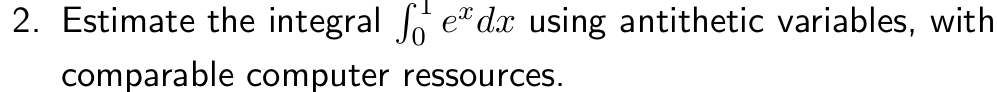

Using antithetic variables involves using the following expression: 

$$Y_i = \frac{e^{U_i}+e^{1-U_i}}{2}$$

Which can be shown to have $E[Y] = E[X]$ where $X$ is defined as in the previous method.

In [15]:
import numpy as np
from random import random

# Set seed
np.random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random())

U = np.array(U)
Y = (np.exp(U) + np.exp(1-U)) / 2

mean_Y = np.mean(Y)
print("Mean of Y:", mean_Y)

# Estimate confidence intervals
s2 = np.var(Y, ddof=1)
alpha = 0.05
lower_bound = mean_Y - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_Y + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of Y: [{lower_bound}, {upper_bound}]")

# Theoretical mean of Y
theoretical_mean_Y = np.exp(1) - 1
print("Theoretical mean of Y:", theoretical_mean_Y)

Mean of Y: 1.7216105302431035
95% confidence interval for the mean of Y: [1.7083626910293228, 1.7348583694568842]
Theoretical mean of Y: 1.718281828459045


In [2]:
print(1.6936509820046652- 1.7173888536416573)
print(1.7083626910293228- 1.7348583694568842)
print(1.7017144791524104- 1.723922728323464)

-0.023737871636992036
-0.026495678427561398
-0.022208249171053573


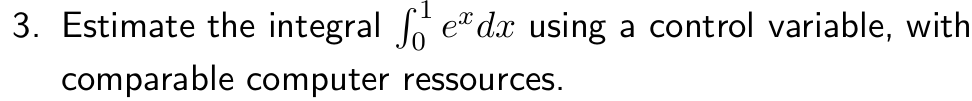

The idea behind covariates is to reformulate the stochastic variable by: 

$$Z_i = X_i + c(Y_i - E[Y])$$

To minimize variance we choose: 

$$c = \frac{-Cov(X,Y)}{Var(Y)}$$

For this specific case we choose $X_i = e^{U_i}$ and $Y_i = U_i$. 

In [27]:
import numpy as np
import random

# Set seed
np.random.seed(0)
random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random.random())

U = np.array(U)
X = np.exp(U)
Y = U
mean_Y = 0.5
c = -np.cov(X, Y)[0, 1] / np.var(Y)
Z = X + c * (Y - mean_Y)

mean_Z = np.mean(Z)
print("Mean of Z:", mean_Z)

# Estimate confidence intervals
s2 = np.var(Z, ddof=1)
alpha = 0.05
lower_bound = mean_Z - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_Z + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of Z: [{lower_bound}, {upper_bound}]")

# Theoretical mean of Z
theoretical_mean_Z = np.exp(1) - 1
print("Theoretical mean of Z:", theoretical_mean_Z)

Mean of Z: 1.7055199178231613
95% confidence interval for the mean of Z: [1.6936509820046652, 1.7173888536416573]
Theoretical mean of Z: 1.718281828459045


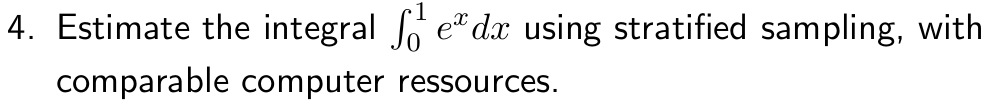

In stratified sampling we stratify the space of $U$ into subspaces and then perform the estimating using all of them. For the case of 10 stratified subspaces we have: 

$$W_i = \frac{e^{U_{i,1/10}} + e^{1/10 + U_{i,2/10}} + ... + e^{9/10+U_{i,10/10}}}{10}$$

In [ ]:
import numpy as np

np.random.seed(0)

strata = 10
n = 100
m = n // strata

V = np.random.rand(m, strata)

U_strat = (np.arange(strata) + V) / strata

W = np.mean(np.exp(U_strat), axis=1)

mean_W = np.mean(W)
print("Mean of W:", mean_W)

s2 = np.var(W, ddof=1)
lower_bound = mean_W - 1.96 * np.sqrt(s2 / m)
upper_bound = mean_W + 1.96 * np.sqrt(s2 / m)
print(f"95% confidence interval for the mean of W: [{lower_bound}, {upper_bound}]")

theoretical_mean = np.exp(1) - 1
print("Theoretical mean:", theoretical_mean)

Mean of W: 1.7128186037379372
95% confidence interval for the mean of W: [1.7017144791524104, 1.723922728323464]
Theoretical mean: 1.718281828459045


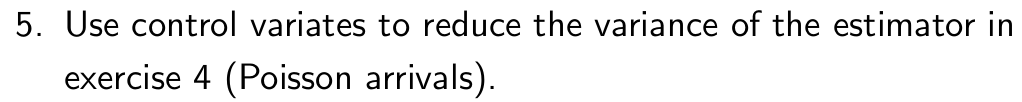

In this case what we wish to estimate is the fraction of blocked costumers which is given as: 

$$X_r = \frac{blocked costumers in replication r}{n_{costumers}}$$

We then have to find a suitable control variate with a known mean, here we can choose the inter-arrival time distribution
as we already calculate this and know its mean which is the mean inter-arrival time.

$$C_r = \frac{1}{n_{costumers}}\sum_{j=1}^{n_{costumers}}A_{r,j}$$

Where:

$$A_{r,j} \sim Exp(\lambda), E[C_r] = mean interarrival$$

Which we assume is correlated with blocking as shorter interarrivals leads to more blocking. We can now construct $Z_r$ as

$$Z_r = X_r + c(C_r - E[C_r]) = X_r + c(C_r - 1)$$

with

$$c = -\frac{Cov(X,C)}{Var(C)}$$



In [3]:
import numpy as np
import heapq
from scipy.stats import t as student_t

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

Xr = []
Cr = []
for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = rng.exponential(scale=mean_service_time)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1
    Xr.append(blocked / n_customers)
    Cr.append(t_now)

c = -np.cov(Xr, Cr)[0, 1] / np.var(Cr)
Zr = np.array(Xr) + c * (np.array(Cr) - np.mean(Cr))

block_fractions = Zr

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Mean blocking fraction: 0.122130
95% CI: [0.119086, 0.125174]
Erlang-B theoretical blocking: 0.121661


In [4]:
print(0.118943- 0.125317)
print(0.119086- 0.125174)

-0.0063740000000000185
-0.00608800000000001


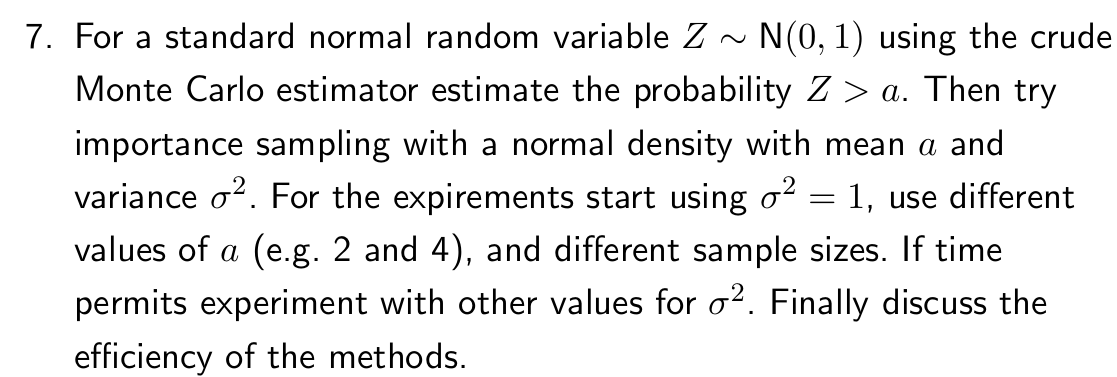

We generate $N$ normally distributed values $Z_i$ and create an indicator function such that $X_i = 1_{Z_i > a}$ and then we can estimate the probability as $P(Z>a) = E[X]$

In [71]:
import numpy as np
import scipy.stats as stats
# Set seed
np.random.seed(0)
N = 10000
a = 2
Z = np.random.normal(loc=0, scale=1, size=N)
X = Z > a

prop = np.mean(X)
print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

N = 10000
a = 4
Z = np.random.normal(loc=0, scale=1, size=N)
X = Z > a

prop = np.mean(X)
print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))


Estimated P(X > 2): 0.0212
Theoretical P(X > 2): 0.02275013194817921
Estimated P(X > 4): 0.0
Theoretical P(X > 4): 3.167124183311998e-05


Now we try to instead use importance sampling, where we wish to find a distribution that puts more mass where the integrand i "important". The exercise suggests that we use $X \sim N(a,1)$. Doing so gives us the likelihood ratio:

$$w(x) = \frac{f(x)}{g(x)} = \frac{e^{-x^2/2}}{e^{-(x-a)^2/2}} = e^{-\frac{1}{2}\big[x^2 - (x-a)^2\big]} = e^{-ax + a^2/2}$$

Which then gives us the probability estimate

$$\hat{\theta}_{\text{IS}} = \frac{1}{n} \sum{i=1}^n \mathbf{1}_{{X_i > a}} \cdot e^{-a X_i + a^2/2}$$

In [5]:
import numpy as np
from scipy import stats

N = 10000
a = 2

Z = np.random.normal(loc=a, scale=1, size=N)

X = Z > a

W = np.exp(-a * Z + 0.5 * a**2)

prop = np.mean(X * W)

print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

N = 10000
a = 4

Z = np.random.normal(loc=a, scale=1, size=N)

X = Z > a

W = np.exp(-a * Z + 0.5 * a**2)

prop = np.mean(X * W)

print(f"Estimated P(X > {a}):", prop)
print(f"Theoretical P(X > {a}):", 1 - stats.norm.cdf(a))

Estimated P(X > 2): 0.022133777111304407
Theoretical P(X > 2): 0.02275013194817921
Estimated P(X > 4): 3.067288348261201e-05
Theoretical P(X > 4): 3.167124183311998e-05


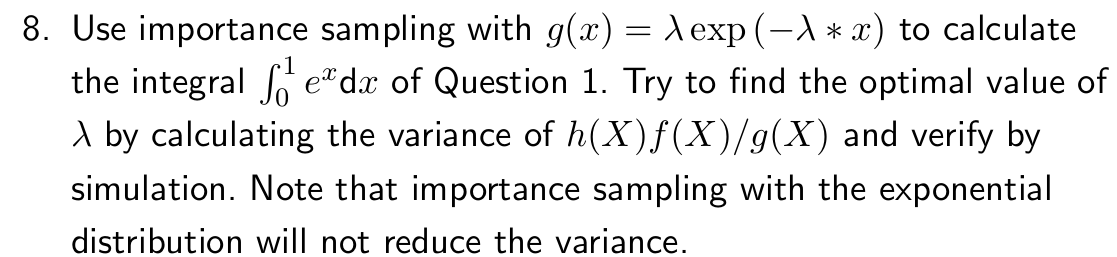

For this case we have: 

 $$\theta = \mathbb{E}_f[h(X)] = \int h(x) f(x), dx = \int_0^1 e^x 1dx$$

 Using importance sampling would then involve the following operations:

$$\theta = \int h(x) \frac{f(x)}{g(x)} g(x), dx = \mathbb{E}_g\left[ h(X) \frac{f(X)}{g(X)} \right]$$

Which when using our given distributions would become: 

$$\theta = \int h(x) \frac{f(x)}{g(x)} g(x), dx = \frac{e^X \cdot \mathbf{1}{[0,1]}(X)}{\lambda e^{-\lambda X}} = \frac{1}{\lambda}e^{(\lambda+1)X}\mathbf{1}{{X \leq 1}}$$

Here the first moment (mean) becomes:

$$ \mathbb{E}\left[\frac{1}{\lambda}e^{(\lambda+1)X}\mathbf{1}_{{X\leq 1}}\right] = \int_0^1 \frac{1}{\lambda}e^{(\lambda+1)x} \cdot \lambda e^{-\lambda x}, dx = \int_0^1 e^x, dx = e - 1 $$

And the second moment (variance) becomes:

$$ \mathbb{E}!\left[\left(\frac{1}{\lambda}e^{(\lambda+1)X}\mathbf{1}_{{X\leq 1}}\right)^2\right] = \int_0^1 \frac{1}{\lambda^2}e^{2(\lambda+1)x} \cdot \lambda e^{-\lambda x}, dx = \frac{1}{\lambda}\int_0^1 e^{(\lambda+2)x}, dx = \frac{1}{\lambda(\lambda+2)}\Big[e^{\lambda+2} - 1\Big] $$

$$\mathrm{Var}\left(\frac{h(X)f(X)}{g(X)}\right) = \frac{e^{\lambda+2} - 1}{\lambda(\lambda+2)} - (e-1)^2$$

Using this formula we can find an optimal lambda as follows: 

In [79]:
import numpy as np
n = 10000
def Var(lambda_):
    var = (np.exp(lambda_+2) - 1)/(lambda_*(lambda_+2)) - (np.exp(1) - 1)**2
    return var

values = np.linspace(0, 10, n)

outputs = Var(values)
optimal_lambda = values[np.argmin(outputs)]
print("Optimal lambda:", optimal_lambda)

Optimal lambda: 1.3551355135513552


C:\Users\emilg\AppData\Local\Temp\ipykernel_15692\930450172.py:4: RuntimeWarning: divide by zero encountered in divide
  var = (np.exp(lambda_+2) - 1)/(lambda_*(lambda_+2)) - (np.exp(1) - 1)**2


Now that we have the optimal $\lambda$ we can estimate the integral using importance sampling.

In [85]:
n = 100000
Z = np.random.exponential(scale=1/optimal_lambda, size=n)
I = Z <= 1
theta = (1/optimal_lambda)*np.exp((optimal_lambda+1)*np.array(Z))*I

true_integral = np.exp(1) - 1
print("True integral:", true_integral)
print("Integral:", np.mean(theta))

True integral: 1.718281828459045
Integral: 1.7190207230830672
